In [1]:
# Imports

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# load in the results
result_dir = "/Users/katiepambakian/Documents/BSc Computer Science/Y3/Dissertation/BeeCommunication/results/"

# date = "2026-03-12/"
# slurm_job = 16290178 -> exibited the correct behaviour
date = "2026-03-16/"
slurm_job = 16342617
batches = [0, 5, 7, 10, 18]


result_dir = result_dir + date + str(slurm_job) + "/"

# start at line number 1
def read_ith_line(i, filename):
    with open(filename, "r") as file:
        for line_number, line in enumerate(file, start=1):
            if (line_number == i):
                return [float(x) for x in line.strip().split()]
            
    # If file exists but doesn't have that many lines
    return []

/var/folders/fz/htwq5qzj5_d0ry3b14hmlrsw0000gn/T/ipykernel_65010/1768176284.py:68: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


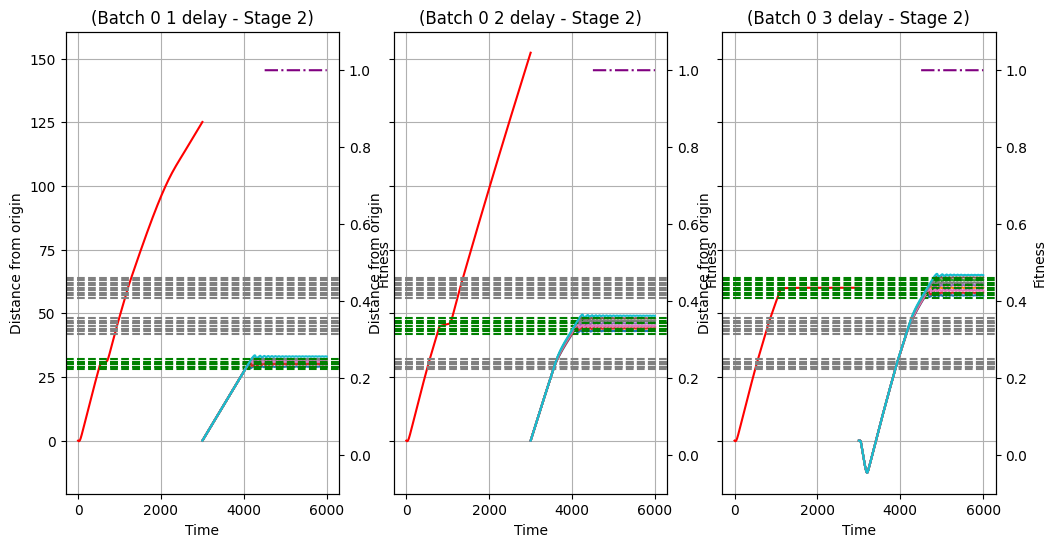

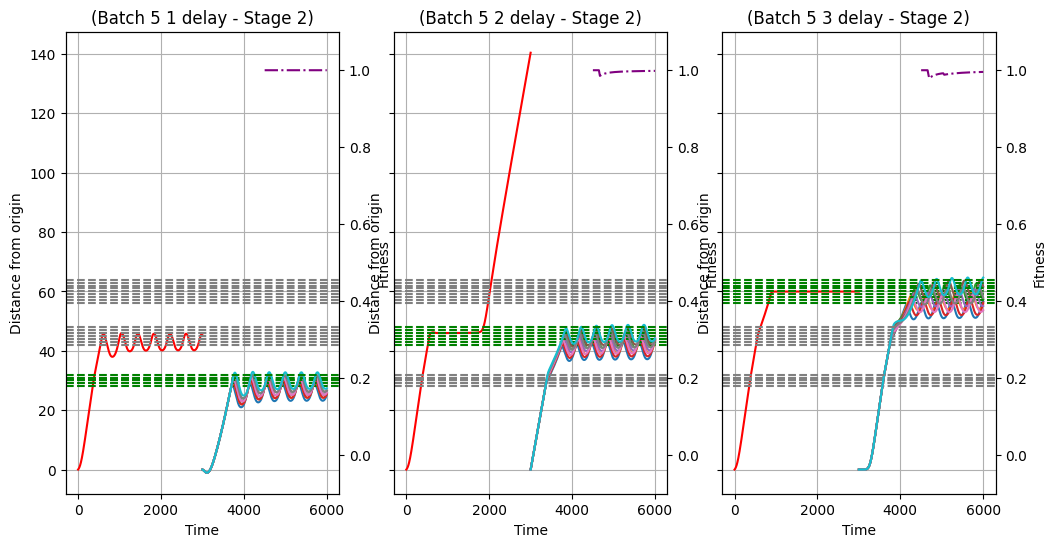

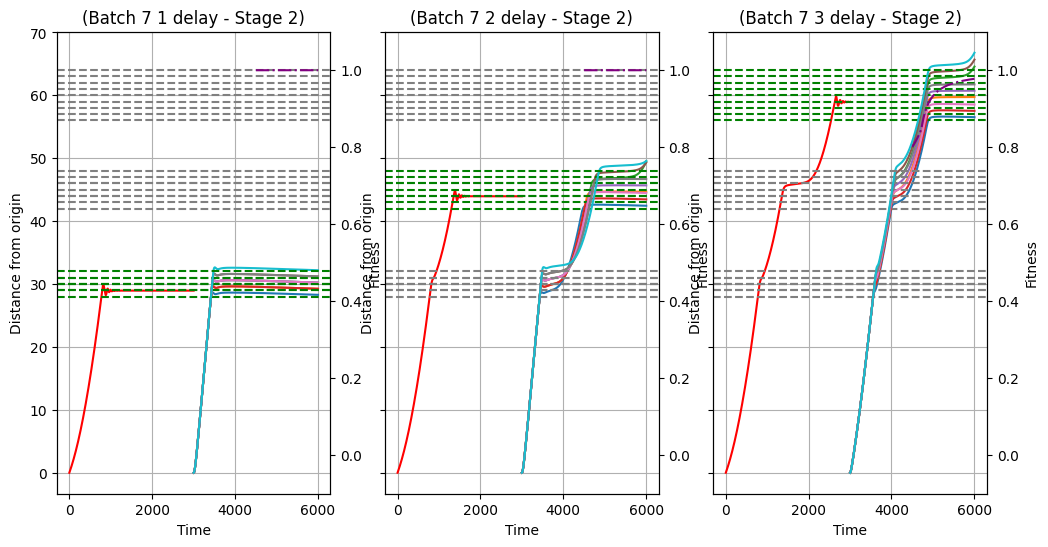

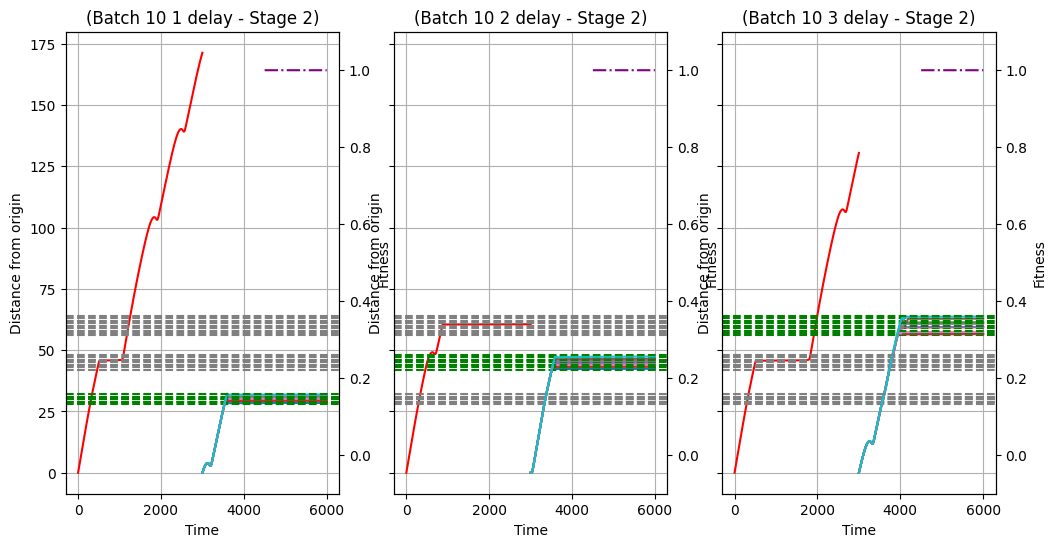

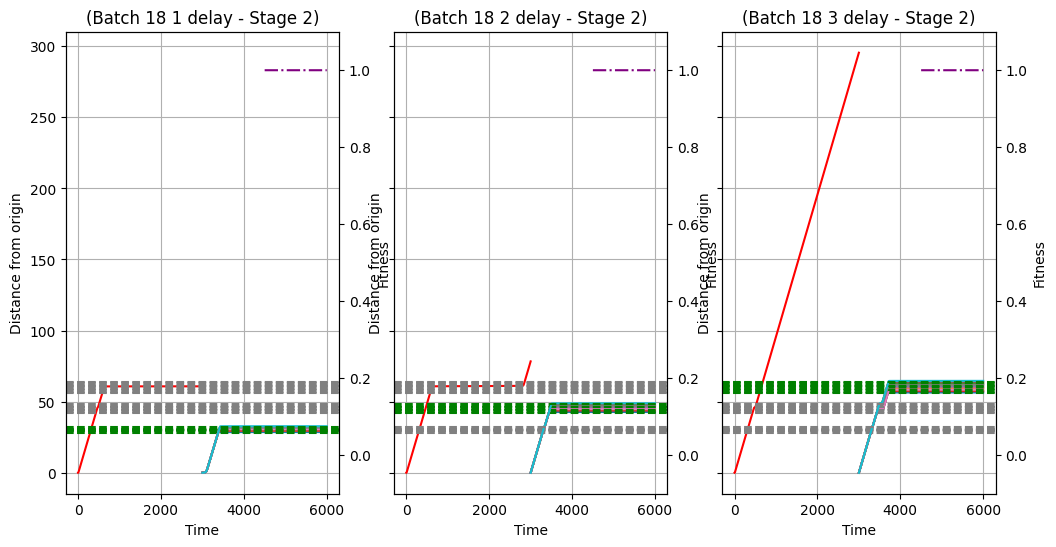

In [2]:
# training phase + pause behaviour
# this is looking at a single file
# phases = ["Phase1", "Phase2"]

delay = "delay"
envs = [1,2,3]
stage = "stage2"

run = 0

colors = [
    "#1F77B4",  # Blue
    "#FF7F0E",  # Orange
    "#2CA02C",  # Green
    "#D62728",  # Red
    "#9467BD",  # Purple
    "#8C564B",  # Brown
    "#E377C2",  # Pink
    "#7F7F7F",  # Grey
    "#17BECF"   # Teal
]

for batch_index, batch in enumerate(batches):
    fig, axes = plt.subplots(1, 3, figsize=(12,6), sharey=True)
    for env in envs:
        # fig, ax = plt.subplots(figsize=(16,10))
        ax = axes[env-1]
        ax2 = ax.twinx()
        # first plot phase 1 and phase 2 in the same plot
        phase1_dir = result_dir + f"batch_{batch}/run_{run}/behavior_{run}_Env{env}_{stage}_Phase1.dat"
        phase2_dir = result_dir + f"batch_{batch}/run_{run}/behavior_{run}_Env{env}_{stage}_Phase2.dat"
        landmark_file = result_dir+ f"batch_{batch}/run_{run}/landmark_location_{run}_env{env}_{stage}_phase2.dat"
        
        behavior1 = []
        behavior1.extend(read_ith_line(1, phase1_dir))
        offset = len(behavior1)
        x = list(range(0, len(behavior1)))
        ax.plot(x, behavior1, label=f"Agent - Phase1", color="red")

        for i in range(0, 9):
            behavior = []
            behavior.extend(read_ith_line(i+1, phase2_dir))
            x = list(range(offset, offset+len(behavior)))
            ax.plot(x, behavior, label=f"Agent - Phase2", color=colors[i])

            landmark = read_ith_line(i+1, landmark_file)
            landmarks = [0,1,2]
            for i in landmarks:
                if (i != env-1):
                    ax.axhline(y=landmark[i], linestyle="--", label=f"Landmark {i}", color="grey")
                else:
                    ax.axhline(y=landmark[i], linestyle="--", label="Food Position", color="green")

        # fitness
        fitness_file = result_dir+ f"batch_{batch}/run_{run}/fitness_{run}_env{env}_{stage}.dat"
        fitness = read_ith_line(1, fitness_file)
        fitness_start = ((len(behavior)+len(behavior1)) - len(fitness))
        fitness_x = range(fitness_start, len(fitness)+fitness_start)

        ax2.plot(fitness_x, fitness, linestyle="dashdot", color="purple")
        ax2.set_ylim(bottom=-0.1, top=1.1)
        ax2.set_ylabel("Fitness")
        # plot it
        ax.set_xlabel("Time")
        ax.set_ylabel("Distance from origin")
        ax.set_title(f"(Batch {batch} {env} {delay} - Stage 2)")
        ax.grid(True)
        fig.show()